# Assignment: Exploratory Data Analysis (EDA)
## Personal Credit Line Assignment

**Regression Analysis — Data Science Engineering**


**Student name:** Octavio Pérez Urbina

---


## 1. Business context and objective

You work on the **Credit Risk** team of a Mexican bank that grants personal loans. Once a customer is approved for a loan, the bank must decide **what credit line amount to grant**. Currently this decision relies heavily on the account executive's judgment, which creates inconsistencies: customers with similar profiles receive very different amounts.

The Risk team wants to move toward a more objective, data-driven criterion. As a first step, they ask you to **explore the historical data of already approved customers** to understand:

- How the granted credit line amount is distributed.
- Which customer variables appear to be most related to the granted amount.
- What data quality issues exist in the database before using it in any model.

> **Note:** The objective of this assignment is exclusively exploratory analysis: understanding the data thoroughly before modeling. The dataset you prepare here will be used later in the course to build a model.

### Available variables

**Response variable (Y):** `monto_linea_credito` — credit line amount granted to the customer, in Mexican pesos (MXN).

**Explanatory variables:**
| Variable | Description |
|---|---|
| `cliente_id` | Unique customer identifier |
| `ingreso_mensual` | Declared monthly income (MXN) |
| `antiguedad_laboral_meses` | Tenure in current job or business (months) |
| `score_buro` | Credit bureau score (typical range 300–850) |
| `edad_cliente` | Customer age (years) |
| `tipo_empleo` | Employed / Self-employed / Business owner |
| `num_productos_banco` | Number of products the customer has with the bank (accounts, cards, insurance, etc.). |
| `pagos_tardios_12m` | Number of payments 30+ days late in the last 12 months |
| `estado_civil` | Customer's marital status |


**Data file:** `credito_bancario.csv`


In [1]:
#Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

---
## Step 1 — Loading and first look at the data

**Instruction:** load the `credito_bancario.csv` file. Review:
- The dataset dimensions (`.shape`)
- The data type of each column (`.dtypes`)
- The first rows (`.head()`)
- General descriptive statistics (`.describe()`, including categorical
  variables with `include='object'`)


In [2]:
df = pd.read_csv("HW3_EDA_Customer_Credit_Data.csv")

print(df.shape)
print(df.dtypes)
display(df.head())
display(df.describe())
display(df.describe(include="object"))

(534, 10)
cliente_id                    int64
ingreso_mensual             float64
antiguedad_laboral_meses    float64
score_buro                  float64
edad_cliente                float64
tipo_empleo                     str
num_productos_banco           int64
pagos_tardios_12m             int64
estado_civil                    str
monto_linea_credito         float64
dtype: object


,cliente_id,ingreso_mensual,antiguedad_laboral_meses,score_buro,edad_cliente,tipo_empleo,num_productos_banco,pagos_tardios_12m,estado_civil,monto_linea_credito
0,1033,NaN,100.0,529.0,39.0,ASALARIADO,2,2,SOLTERO,197127.12
1,1172,28791.61,34.0,693.0,39.0,Asalariado,1,0,Soltero,243856.94
2,1195,15590.11,70.0,638.0,42.0,Asalariado,4,1,Divorciado,196710.87
3,1116,20499.31,170.0,604.0,33.0,independiente,1,2,casado,206261.54
4,1049,30770.77,39.0,585.0,51.0,ASALARIADO,2,2,casado,228405.37


,cliente_id,ingreso_mensual,antiguedad_laboral_meses,score_buro,edad_cliente,num_productos_banco,pagos_tardios_12m,monto_linea_credito
count,534.000000,516.000000,521.000000,517.000000,534.000000,534.00000,534.000000,534.000000
mean,1280.084270,24947.894884,72.928983,636.947776,38.537453,3.00000,1.509363,221719.933502
std,190.411972,8279.041397,41.529609,84.269474,10.073161,1.40356,1.210843,36807.791248
min,1001.000000,6000.000000,4.000000,391.000000,18.000000,1.00000,0.000000,107163.280000
25%,1134.250000,19280.170000,43.000000,582.000000,32.000000,2.00000,1.000000,197038.657500
50%,1267.500000,25075.500000,66.000000,642.000000,39.000000,3.00000,1.000000,223090.940000
75%,1400.750000,30365.950000,94.000000,693.000000,45.000000,4.00000,2.000000,246131.167500
max,2014.000000,49767.830000,299.000000,850.000000,66.000000,8.00000,6.000000,327996.530000


/var/folders/8q/9zk58sl93rx81t6np6mvjx200000gn/T/ipykernel_78318/746296448.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object"))


,tipo_empleo,estado_civil
count,534,534
unique,14,16
top,Asalariado,Casado
freq,79,63


**Interpretation (Step 1):** does the number of rows and columns match
what you expected? Does any data type look incorrect at first glance?

> _Your interpretation:_ 534 rows and 10 columns match the variable list. `tipo_empleo` and `estado_civil` are text, as expected; the rest are numeric. `ingreso_mensual`, `antiguedad_laboral_meses` and `score_buro` already show fewer counts than 534, so there are missing values.


---
## Step 2 — Data quality

Before analyzing relationships between variables, you need to confirm that
the data is reliable.

**Missing values:**
- Count the null values per column.
- Which columns have nulls? What percentage of the total do they represent?
- Decide on and apply a treatment strategy (drop rows, impute with
  mean/median, etc.) and **justify your choice** in the interpretation cell.


In [3]:
missing = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "%": (df.isna().mean() * 100).round(2),
}).sort_values("n_missing", ascending=False)

display(missing[missing["n_missing"] > 0])

,n_missing,%
ingreso_mensual,18,3.37
score_buro,17,3.18
antiguedad_laboral_meses,13,2.43


In [4]:
df["ingreso_mensual"] = df["ingreso_mensual"].fillna(df["ingreso_mensual"].median())
df["antiguedad_laboral_meses"] = df["antiguedad_laboral_meses"].fillna(df["antiguedad_laboral_meses"].median())
df["score_buro"] = df["score_buro"].fillna(df["score_buro"].median())

display(df.isna().sum())

cliente_id                  0
ingreso_mensual             0
antiguedad_laboral_meses    0
score_buro                  0
edad_cliente                0
tipo_empleo                 0
num_productos_banco         0
pagos_tardios_12m           0
estado_civil                0
monto_linea_credito         0
dtype: int64

> _Your interpretation: what strategy did you choose and why?_ 

we only have nulls in  `ingreso_mensual` (3.4%), `score_buro` (3.2%) and `antiguedad_laboral_meses` (2.4%). I fill each with the median because the share is small.


**Format inconsistencies:**
- Review the unique values of the categorical columns.
- Identify inconsistencies (uppercase/lowercase, extra spaces, etc.) and
  standardize them.


In [5]:
for col in ["tipo_empleo", "estado_civil"]:
    print(col)
    print(df[col].value_counts())
    print()

tipo_empleo
tipo_empleo
Asalariado          79
asalariado          79
ASALARIADO          71
 Asalariado         62
 Independiente      40
INDEPENDIENTE       39
independiente       37
 Negocio propio     29
Negocio propio      27
Independiente       26
NEGOCIO PROPIO      22
negocio propio      21
 negocio propio      1
  Negocio propio     1
Name: count, dtype: int64

estado_civil
estado_civil
 Casado         63
 Soltero        61
casado          61
soltero         55
CASADO          52
Casado          51
Soltero         48
SOLTERO         43
DIVORCIADO      21
 Divorciado     16
 Union libre    14
Union libre     12
UNION LIBRE     11
divorciado      10
union libre      9
Divorciado       7
Name: count, dtype: int64



In [6]:
df["tipo_empleo"] = df["tipo_empleo"].str.strip().str.title()
df["estado_civil"] = df["estado_civil"].str.strip().str.title()

print(df["tipo_empleo"].value_counts())
print()
print(df["estado_civil"].value_counts())

tipo_empleo
Asalariado        291
Independiente     142
Negocio Propio    101
Name: count, dtype: int64

estado_civil
Casado         227
Soltero        207
Divorciado      54
Union Libre     46
Name: count, dtype: int64


> _Your interpretation: what inconsistencies did you find?_ 

The same categories were stored with spaces and mixed upper qand lower case (`ASALARIADO`, ` Asalariado`, `asalariado`). I normalize it to 3 and 4 values 

**Duplicates:**
- Look for duplicate or near-duplicate records (the same customer captured
  more than once, even with a different `cliente_id`).
- Decide how to treat them and apply your decision.

In [7]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Repeated cliente_id:", df["cliente_id"].duplicated().sum())

cols = [c for c in df.columns if c != "cliente_id"]
print("Same profile, different cliente_id:", df.duplicated(subset=cols).sum())

df = df.drop_duplicates(subset=cols).reset_index(drop=True)
print("Rows after dropping near-duplicates:", len(df))

Fully duplicated rows: 0
Repeated cliente_id: 0
Same profile, different cliente_id: 14
Rows after dropping near-duplicates: 520


> _Your interpretation: how many duplicates did you find and what did you decide to do?_ 

No `cliente_id` repeats. There were 10 pairs with the same profile and a different id. i/ dropped the extra pair

---
## Step 3 — Univariate analysis of the response variable

**Analyze `monto_linea_credito` on its own.**

Visualizations to generate:
- Histogram (with density curve)
- Boxplot

Metrics to calculate:
- Mean, median, standard deviation
- Skewness
- Minimum and maximum


In [8]:
y = df["monto_linea_credito"]

resumen = pd.Series({
    "mean": y.mean(),
    "median": y.median(),
    "std": y.std(),
    "skewness": y.skew(),
    "min": y.min(),
    "max": y.max(),
}).round(2)
display(resumen)

mean        221560.12
median      222818.90
std          36758.08
skewness        -0.02
min         107163.28
max         327996.53
dtype: float64

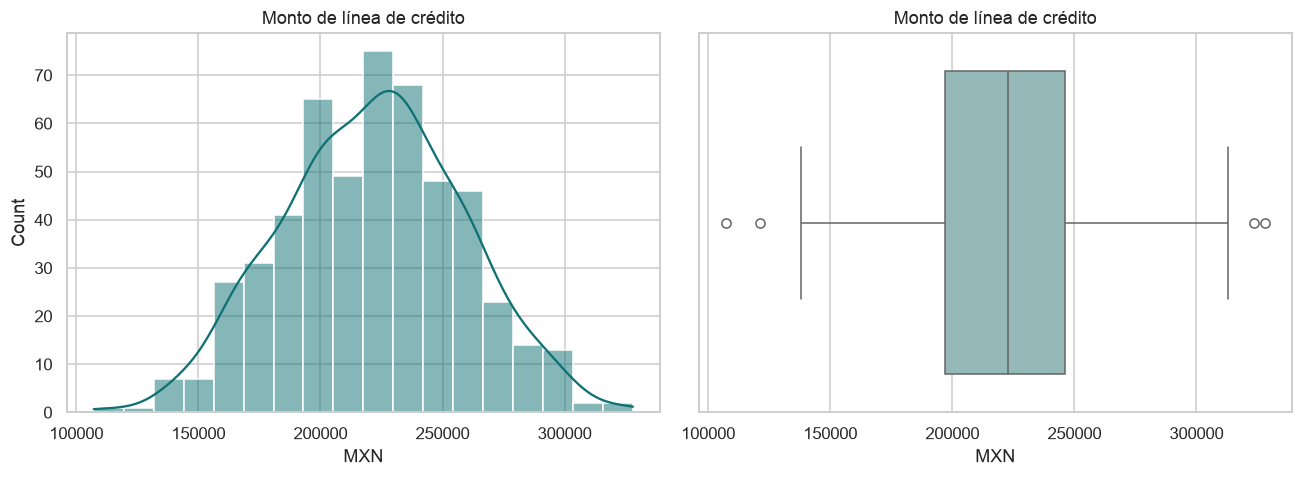

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(df["monto_linea_credito"], kde=True, ax=axes[0], color="#0F7173")
axes[0].set_title("Monto de línea de crédito")
axes[0].set_xlabel("MXN")

sns.boxplot(x=df["monto_linea_credito"], ax=axes[1], color="#8FBFBF")
axes[1].set_title("Monto de línea de crédito")
axes[1].set_xlabel("MXN")

plt.tight_layout()
plt.show()

**Interpretation (Step 3):** based on the shape of the histogram, the
mean vs. the median, and the skewness value: is it reasonable to treat
`monto_linea_credito` as approximately Normal? Are there signs of outliers?

> _Your interpretation:_ 

Yes, mean and median are almost the same and skewness is almost 0 so it can be treated as a normal


---
## Step 4 — Univariate analysis of the predictors

**Variable visualization:**

- **Numerical:** histogram or boxplot for each one.
- **Categorical:** bar chart with the count of each category.

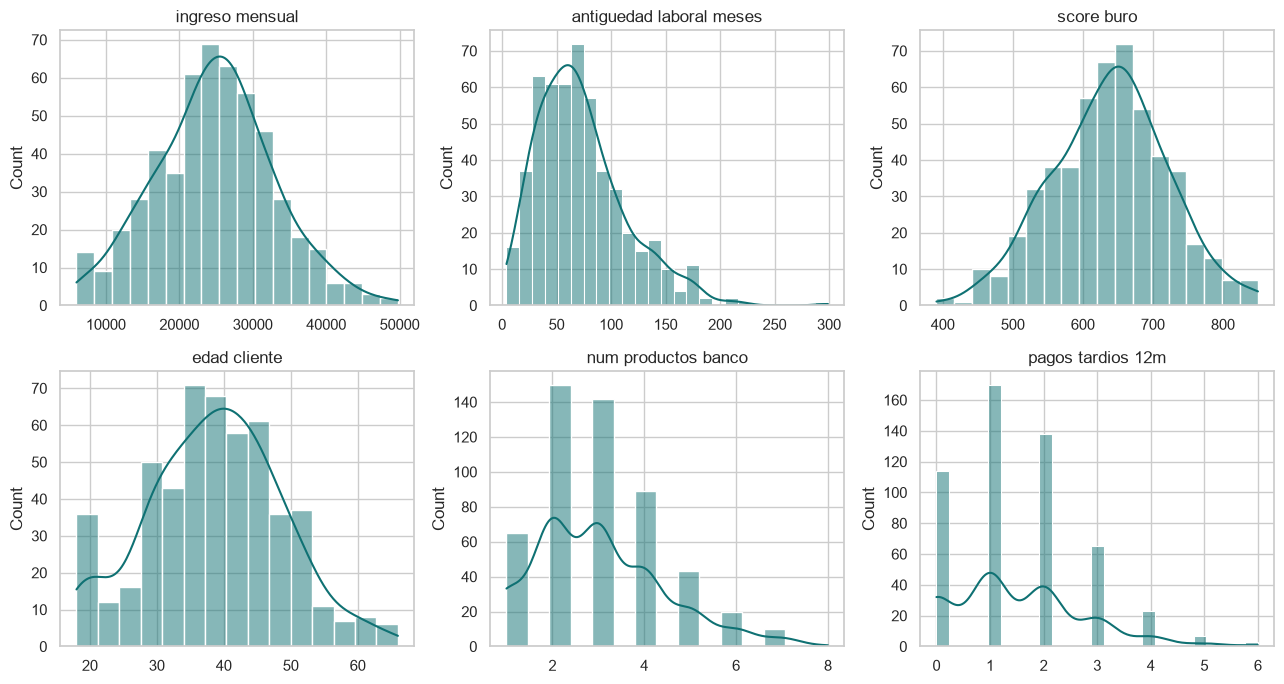

In [9]:
num_cols = ["ingreso_mensual", "antiguedad_laboral_meses", "score_buro",
            "edad_cliente", "num_productos_banco", "pagos_tardios_12m"]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#0F7173")
    ax.set_title(col.replace("_", " "))
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

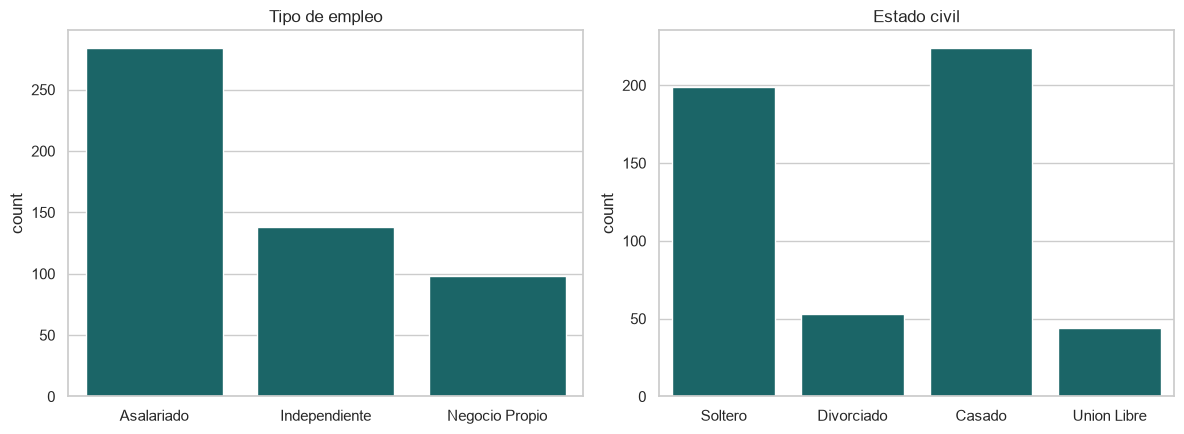

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.countplot(data=df, x="tipo_empleo", ax=axes[0], color="#0F7173")
axes[0].set_title("Tipo de empleo")
axes[0].set_xlabel("")

sns.countplot(data=df, x="estado_civil", ax=axes[1], color="#0F7173")
axes[1].set_title("Estado civil")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

**Interpretation (Step 4):** does any numerical variable show a
distribution clearly different from the others (heavily skewed, with
outliers)? Are the categories of the categorical variables balanced, or are
there dominant categories?

> _Your interpretation:_ 

`antiguedad_laboral_meses` is right-skewed, income, score and age look symmetric. `tipo_empleo` and `estado_civil` are unbalanced: Asalariado and Casado/Soltero are the mayority, while Negocio propio, Divorciado and Unión libre are smaller groups.


---
## Step 5 — Building `historial_pagos`

The dataset does not directly include a "payment history" category: you
only have `pagos_tardios_12m` (number of payments 30+ days late in the last
year).

**Creating a new variable:**
Create a new categorical variable `historial_pagos` with three levels:
**Bueno** (Good), **Regular**, **Malo** (Bad), based on `pagos_tardios_12m`.

You decide the thresholds that separate each category. As business
guidance: a customer with 0 or very few late payments should classify as
"Bueno"; a customer with many late payments should classify as "Malo".
There is no single correct answer, but your rule must be reasonable and
explicit.

After creating it, check how many customers fall into each category.


In [11]:
df["historial_pagos"] = pd.cut(
    df["pagos_tardios_12m"],
    bins=[-0.1, 1, 2, 99],
    labels=["Bueno", "Regular", "Malo"],
)

display(df["historial_pagos"].value_counts())

historial_pagos
Bueno      284
Regular    138
Malo        98
Name: count, dtype: int64

**Interpretation (Step 5):** what thresholds did you choose and why? How
did the distribution of customers across the three categories turn out?
Would you change your thresholds if you saw that one category had almost no
customers?

> _Your interpretation:_ 

Bueno = 0–1 late payments, Regular = 2, Malo = 3 or more. That keeps three groups with enough customers (about 284 / 138 / 98). There are few 5-6 late payments so it was not worth it


---
## Step 6 — Bivariate analysis: predictors vs. credit line amount

**Explanatory variables vs `monto_linea_credito`:**

- **Numerical predictors:** scatterplot of each one against
  `monto_linea_credito`.
- **Categorical predictors** (including your new variable): boxplot of
  `monto_linea_credito` by category.
- **Correlation matrix:** calculate the correlation of the numerical
  variables (including `monto_linea_credito`) and visualize it with a
  heatmap.


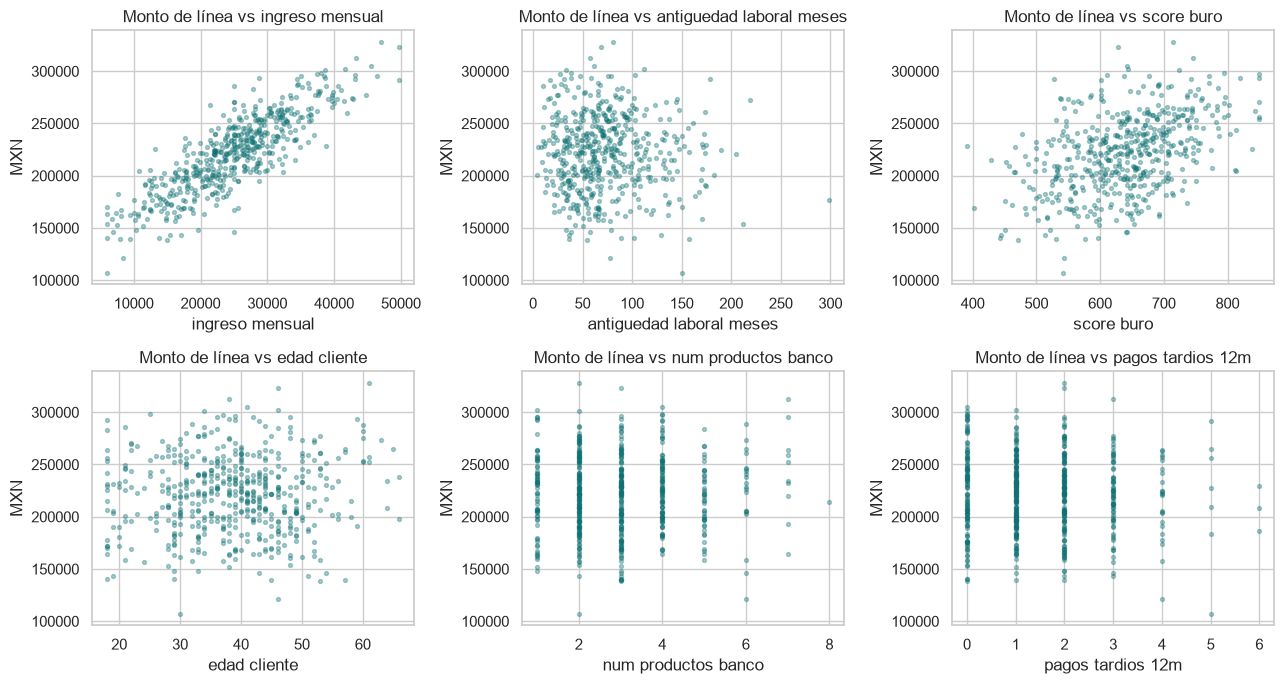

In [12]:
num_preds = ["ingreso_mensual", "antiguedad_laboral_meses", "score_buro",
             "edad_cliente", "num_productos_banco", "pagos_tardios_12m"]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.ravel(), num_preds):
    ax.scatter(df[col], df["monto_linea_credito"], s=8, alpha=0.35, color="#0F7173")
    ax.set_title(f"Monto de línea vs {col.replace('_', ' ')}")
    ax.set_xlabel(col.replace("_", " "))
    ax.set_ylabel("MXN")
plt.tight_layout()
plt.show()

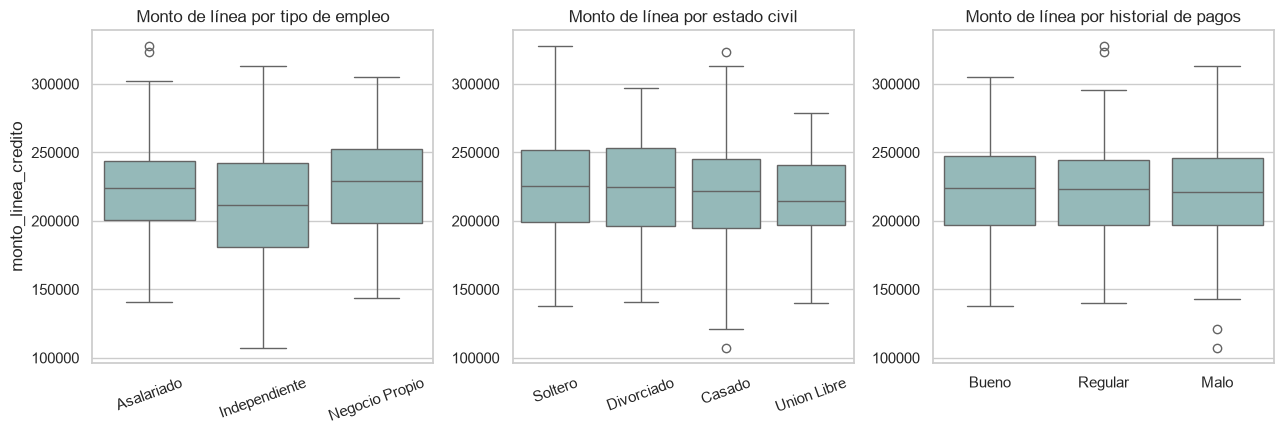

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

sns.boxplot(data=df, x="tipo_empleo", y="monto_linea_credito", ax=axes[0], color="#8FBFBF")
axes[0].set_title("Monto de línea por tipo de empleo")
axes[0].tick_params(axis="x", rotation=20)
axes[0].set_xlabel("")

sns.boxplot(data=df, x="estado_civil", y="monto_linea_credito", ax=axes[1], color="#8FBFBF")
axes[1].set_title("Monto de línea por estado civil")
axes[1].tick_params(axis="x", rotation=20)
axes[1].set_xlabel("")
axes[1].set_ylabel("")

sns.boxplot(data=df, x="historial_pagos", y="monto_linea_credito",
            order=["Bueno", "Regular", "Malo"], ax=axes[2], color="#8FBFBF")
axes[2].set_title("Monto de línea por historial de pagos")
axes[2].set_xlabel("")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

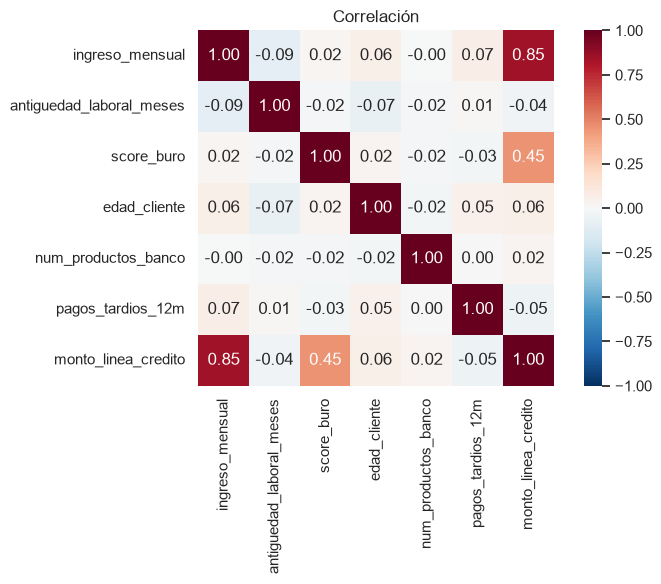

In [14]:
corr_cols = ["ingreso_mensual", "antiguedad_laboral_meses", "score_buro",
             "edad_cliente", "num_productos_banco", "pagos_tardios_12m",
             "monto_linea_credito"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Correlación")
plt.tight_layout()
plt.show()

**Interpretation (Step 6):** which 2 or 3 variables show the strongest
relationship (visual or numeric) with `monto_linea_credito`? Does any
categorical variable seem to separate the amounts well between groups? Is
there any variable you expected to matter that, according to the EDA, shows
no clear relationship (a candidate "distractor")?

> _Your interpretation:_ 

`ingreso_mensual`  and `score_buro`  are the only correlations with monto de credito. The categorical variables have little correlations. Age, tenure, number of products and late payments look like noise.


---
## Final conclusion

**Instruction:** write a 1-2 paragraph conclusion addressed to the Credit
Risk team, answering:

1. Is the database ready to be used in a model, or were there unresolved
   data quality issues?
2. Based on the EDA, which variables seem most promising for explaining the
   granted credit line amount, and why?
3. What would you recommend to the Risk team before building a formal model
   with this data (for example, about variables to review, `historial_pagos`
   thresholds, or data quality)?

> _Your conclusion:_ The file is usable after the cleaning above: a few percent of values were imputed, categories were standardized, and 10 copied profiles were removed. There are no remaining missing values in the response.

The variables that should build a first model are `ingreso_mensual` and `score_buro`. Before modeling I would keep `historial_pagos` only as a help, not as a main indicator. it does not move the monto 